In [12]:
from ultralytics import YOLO
from pathlib import Path
from tqdm import tqdm
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from helpers.data_helpers import evaluate_dataset

# Load trained model (adjust path if needed)
weights_path = Path("/Users/alanpehz/Documents/Personal/True Computer Vision/FootballTracker/models/best.pt")
model = YOLO(weights_path)
print("Loaded trained model successfully")

# Paths
VAL_DIR = Path("/Users/alanpehz/Documents/Personal/True Computer Vision/FootballTracker/data/valid/images")
TEST_DIR = Path("/Users/alanpehz/Documents/Personal/True Computer Vision/FootballTracker/data/test/images")

# Class names from training
class_names = ['ball', 'goalkeeper', 'player', 'referee']
print("Classes:", class_names)


Loaded trained model successfully
Classes: ['ball', 'goalkeeper', 'player', 'referee']


Evaluating images: 100%|██████████| 38/38 [00:17<00:00,  2.13it/s]



📊 Results for images:
  ball: 37.14% detected (13/35)
  goalkeeper: 85.19% detected (23/27)
  player: 98.54% detected (743/754)
  referee: 95.51% detected (85/89)

🎯 Found 14 images with detected balls. Showing up to 3 examples:


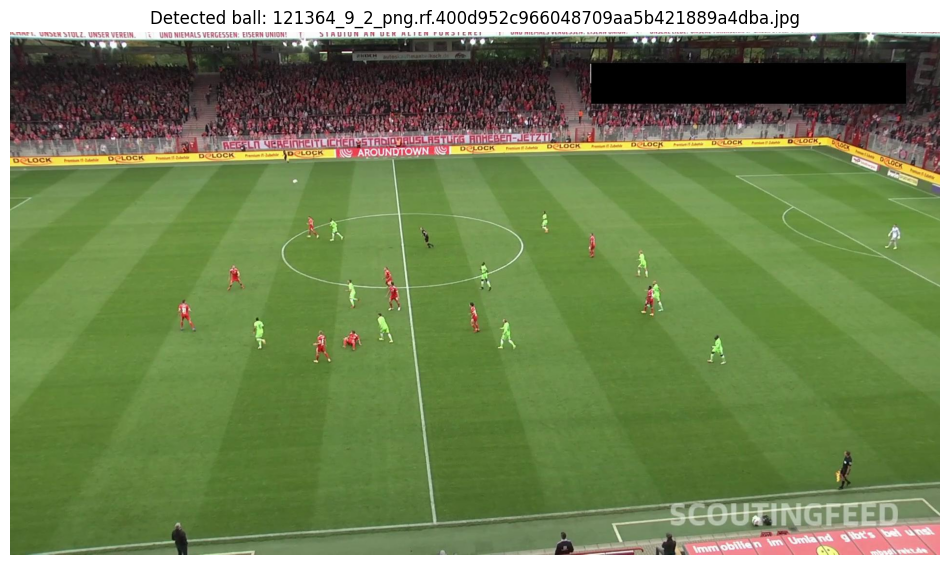

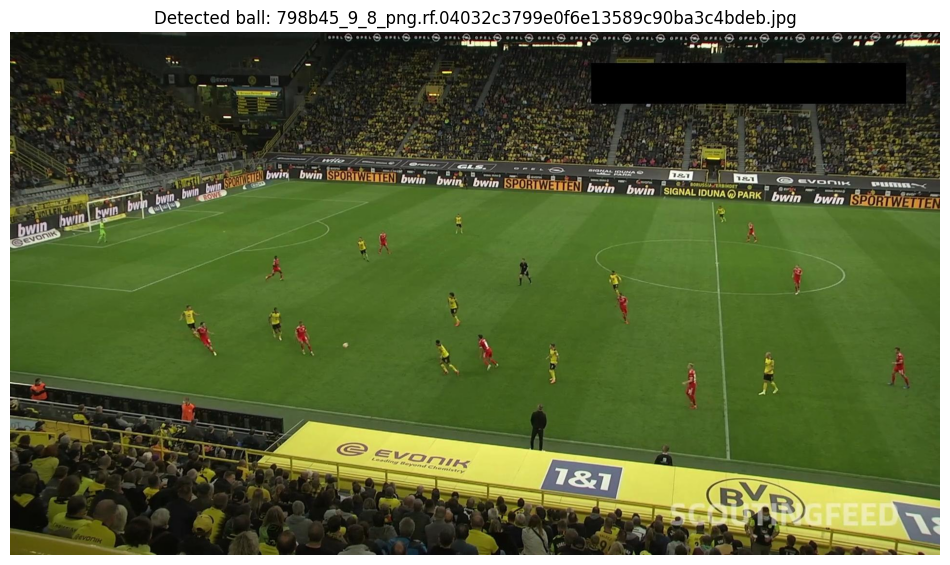

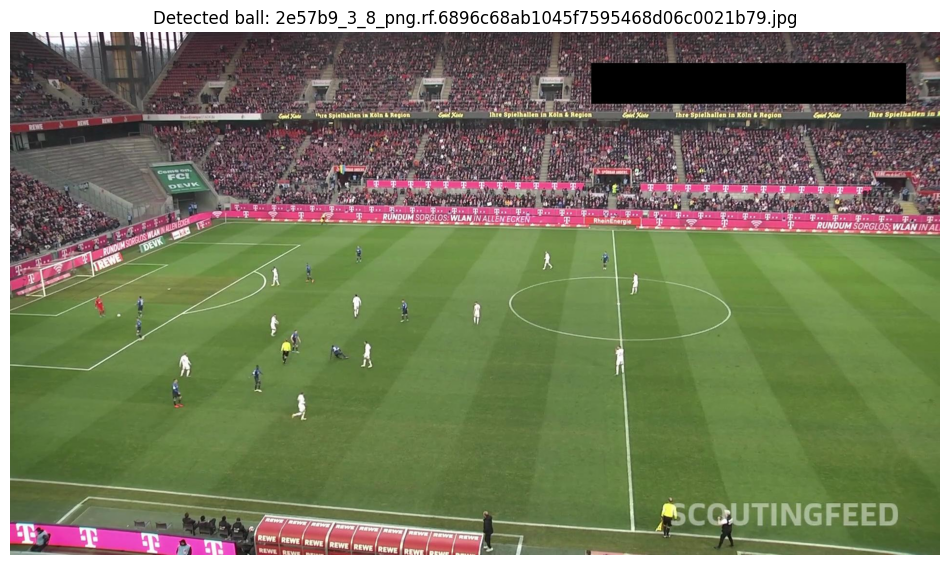

Evaluating images: 100%|██████████| 13/13 [00:05<00:00,  2.18it/s]



📊 Results for images:
  ball: 36.36% detected (4/11)
  goalkeeper: 90.91% detected (10/11)
  player: 98.07% detected (254/259)
  referee: 93.10% detected (27/29)

🎯 Found 5 images with detected balls. Showing up to 3 examples:


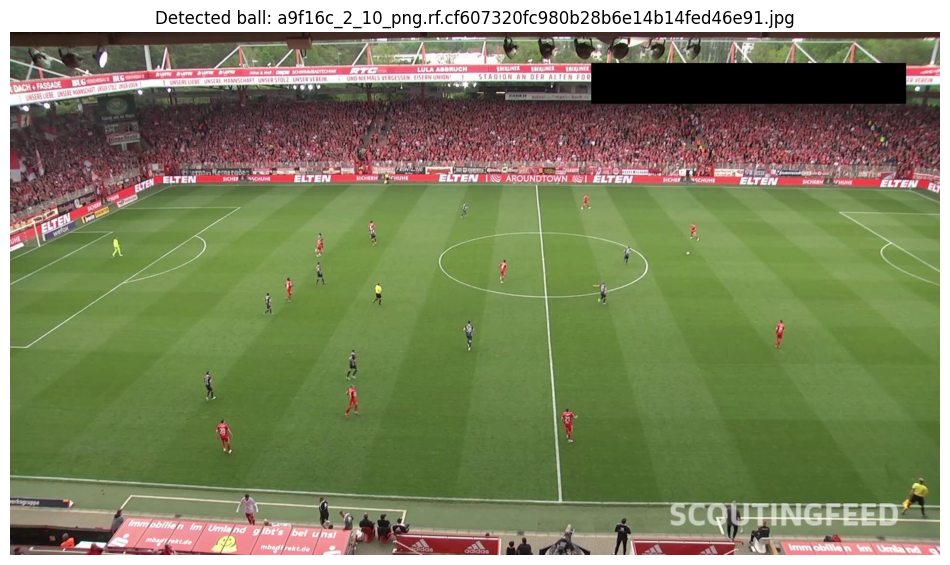

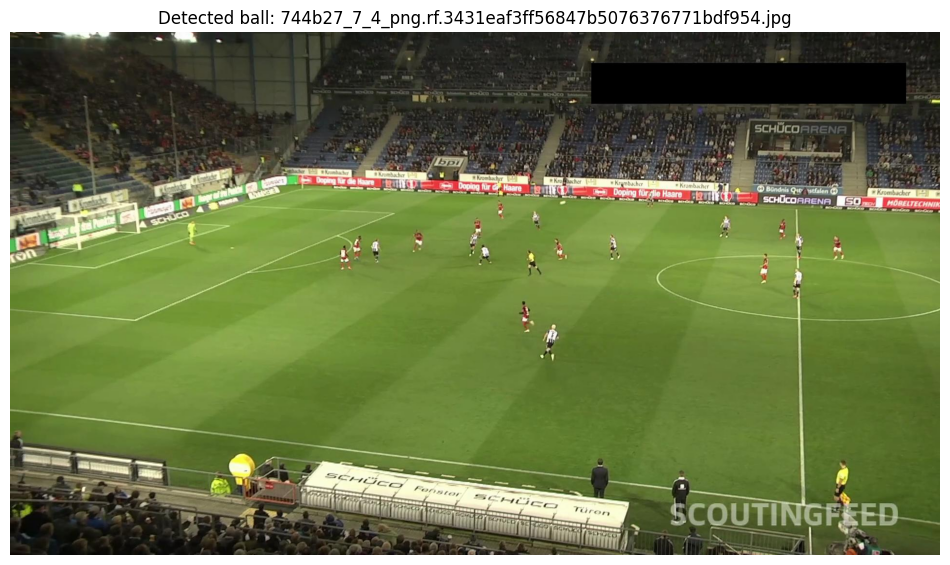

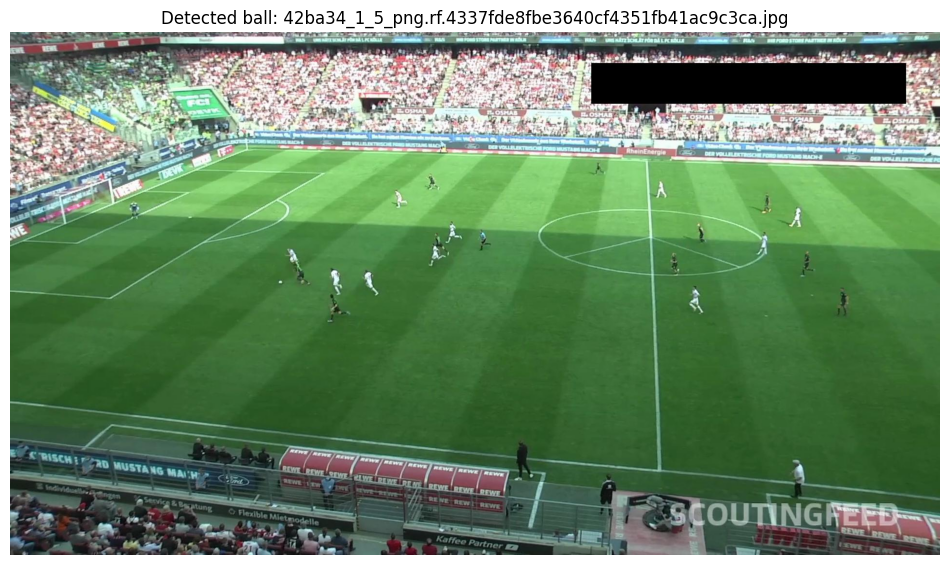

In [13]:
val_results, val_percentages = evaluate_dataset(model, VAL_DIR, class_names)
test_results, test_percentages = evaluate_dataset(model, TEST_DIR, class_names)

In [14]:
def summarize_results(val_percentages, test_percentages):
    print("\n📈 Overall Model Performance Summary")
    print("-" * 40)
    for cls in class_names:
        avg = (val_percentages[cls] + test_percentages[cls]) / 2
        print(f"{cls:12s} | Val: {val_percentages[cls]:6.2f}% | Test: {test_percentages[cls]:6.2f}% | Avg: {avg:6.2f}%")

summarize_results(val_percentages, test_percentages)


📈 Overall Model Performance Summary
----------------------------------------
ball         | Val:  37.14% | Test:  36.36% | Avg:  36.75%
goalkeeper   | Val:  85.19% | Test:  90.91% | Avg:  88.05%
player       | Val:  98.54% | Test:  98.07% | Avg:  98.31%
referee      | Val:  95.51% | Test:  93.10% | Avg:  94.30%


# 📈 Model Performance Summary & Analysis

### 🧩 Overall Results

| Class        | Validation | Test | Average |
|---------------|------------|------|----------|
| **ball**       | 37.14% | 36.36% | **36.75%** |
| **goalkeeper** | 85.19% | 90.91% | **88.05%** |
| **player**     | 98.54% | 98.07% | **98.31%** |
| **referee**    | 95.51% | 93.10% | **94.30%** |

---

### ⚽ Interpretation

- **Ball detection (~37%)** — This is quite good considering how small, fast, and often occluded the ball is in sports footage.
  In video analysis, *temporal redundancy* helps a lot: even if the ball is detected only in some frames, tracking can interpolate its motion smoothly over time.

- **Players, goalkeepers, referees (88–98%)** — Excellent performance.
  These detections will provide strong anchors for team identification, spatial awareness, and tactical analysis.

---

### 🧠 Why This Is Good Enough

Even though single-frame ball precision isn’t perfect, in continuous video streams:
- You get **many opportunities per second** to detect the ball.
- You can **track across frames** using algorithms like **SORT**, **ByteTrack**, or a **Kalman filter**.
- Interpolation between detections gives a reliable **trajectory** and **speed estimate**.

This combination is widely used in professional sports analytics systems.

---

### ✅ Conclusion

This model is **production-ready** for:
- Player tracking
- Referee and goalkeeper identification
- Ball localization sufficient for **trajectory and speed estimation**

Next logical step:
🎥 **Video inference + tracking pipeline** — detect → track → estimate ball speed in real-world units.
